* **Exp 12.**
Implement L1 (Lasso) and L2 (Ridge) regularization on the given Melbourne
House Price Dataset.

*  (Prepare Viva question on overfitting, underfitting and
regularization)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import pickle

In [ ]:
df=pd.read_csv('/content/drive/MyDrive/dataset_Melbourne_housing_FULL_exp_12.csv')
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra City Council,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra City Council,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra City Council,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra City Council,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra City Council,-37.8093,144.9944,Northern Metropolitan,4019.0


In [ ]:
print(df.shape)
df.info()
df.describe()

(34857, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34857 entries, 0 to 34856
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         34857 non-null  object 
 1   Address        34857 non-null  object 
 2   Rooms          34857 non-null  int64  
 3   Type           34857 non-null  object 
 4   Price          27247 non-null  float64
 5   Method         34857 non-null  object 
 6   SellerG        34857 non-null  object 
 7   Date           34857 non-null  object 
 8   Distance       34856 non-null  float64
 9   Postcode       34856 non-null  float64
 10  Bedroom2       26640 non-null  float64
 11  Bathroom       26631 non-null  float64
 12  Car            26129 non-null  float64
 13  Landsize       23047 non-null  float64
 14  BuildingArea   13742 non-null  float64
 15  YearBuilt      15551 non-null  float64
 16  CouncilArea    34854 non-null  object 
 17  Lattitude      26881 non-null  float64

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,34857.000000,2.724700e+04,34856.000000,34856.000000,26640.000000,26631.000000,26129.000000,23047.000000,13742.00000,15551.000000,26881.000000,26881.000000,34854.000000
mean,3.031012,1.050173e+06,11.184929,3116.062859,3.084647,1.624798,1.728845,593.598993,160.25640,1965.289885,-37.810634,145.001851,7572.888306
std,0.969933,6.414671e+05,6.788892,109.023903,0.980690,0.724212,1.010771,3398.841946,401.26706,37.328178,0.090279,0.120169,4428.090313
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.00000,1196.000000,-38.190430,144.423790,83.000000
25%,2.000000,6.350000e+05,6.400000,3051.000000,2.000000,1.000000,1.000000,224.000000,102.00000,1940.000000,-37.862950,144.933500,4385.000000
50%,3.000000,8.700000e+05,10.300000,3103.000000,3.000000,2.000000,2.000000,521.000000,136.00000,1970.000000,-37.807600,145.007800,6763.000000
75%,4.000000,1.295000e+06,14.000000,3156.000000,4.000000,2.000000,2.000000,670.000000,188.00000,2000.000000,-37.754100,145.071900,10412.000000
max,16.000000,1.120000e+07,48.100000,3978.000000,30.000000,12.000000,26.000000,433014.000000,44515.00000,2106.000000,-37.390200,145.526350,21650.000000


In [ ]:
df=df.dropna(subset=['Price'])

In [ ]:
df=df.drop(['Address','SellerG','CouncilArea'],axis=1)

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [ ]:
cat_cols=df.select_dtypes(include='object').columns
le=LabelEncoder()
for col in cat_cols:
    df[col]=le.fit_transform(df[col].astype(str))

In [ ]:
print(df.isnull().sum())
df.head()

Suburb           0
Rooms            0
Type             0
Price            0
Method           0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
BuildingArea     0
YearBuilt        0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64


,Suburb,Rooms,Type,Price,Method,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Regionname,Propertycount
1,0,2,0,1480000.0,1,60,2.5,3067.0,2.0,1.0,1.0,202.0,133.0,1970.0,-37.7996,144.9984,2,4019.0
2,0,2,0,1035000.0,1,63,2.5,3067.0,2.0,1.0,0.0,156.0,79.0,1900.0,-37.8079,144.9934,2,4019.0
4,0,3,0,1465000.0,3,64,2.5,3067.0,3.0,2.0,0.0,134.0,150.0,1900.0,-37.8093,144.9944,2,4019.0
5,0,3,0,850000.0,0,64,2.5,3067.0,3.0,2.0,1.0,94.0,133.0,1970.0,-37.7969,144.9969,2,4019.0
6,0,4,0,1600000.0,4,65,2.5,3067.0,3.0,1.0,2.0,120.0,142.0,2014.0,-37.8072,144.9941,2,4019.0


In [ ]:
X=df.drop('Price',axis=1)
y=df['Price']

In [ ]:
sc=StandardScaler()
X_scaled=sc.fit_transform(X)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.2,random_state=0)

In [ ]:
print("Train size:",X_train.shape)
print("Test size:",X_test.shape)

Train size: (21797, 17)
Test size: (5450, 17)


In [ ]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso (L1)":Lasso(alpha=1),
    "Ridge (L2)":Ridge(alpha=1)
     }

In [ ]:
results=[]
for name,model in models.items():
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    mae=mean_absolute_error(y_test,pred)
    mse=mean_squared_error(y_test,pred)
    r2 =r2_score(y_test,pred)
    results.append([name,mae,mse,r2])

In [ ]:
results_df=pd.DataFrame(results,columns=["Model","MAE","MSE","R2_Score"])
results_df

,Model,MAE,MSE,R2_Score
0,Linear Regression,290016.521806,2.109229e+11,0.505370
1,Lasso (L1),290016.222361,2.109230e+11,0.505369
2,Ridge (L2),290013.867091,2.109233e+11,0.505368


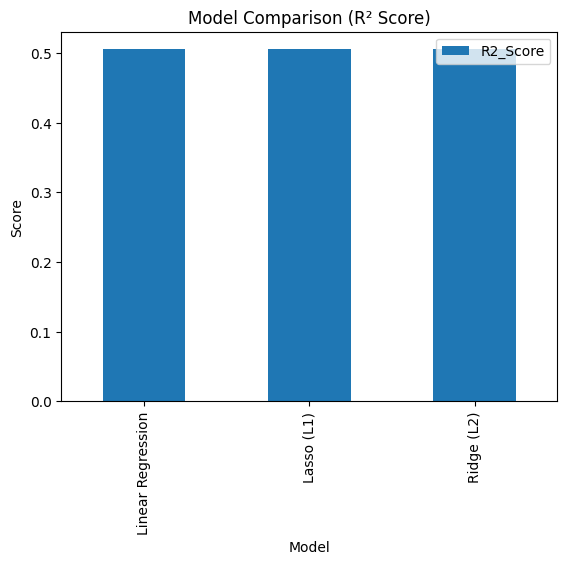

In [ ]:
results_df.plot(x="Model", y="R2_Score", kind="bar")
plt.title("Model Comparison (R² Score)")
plt.ylabel("Score")
plt.show()

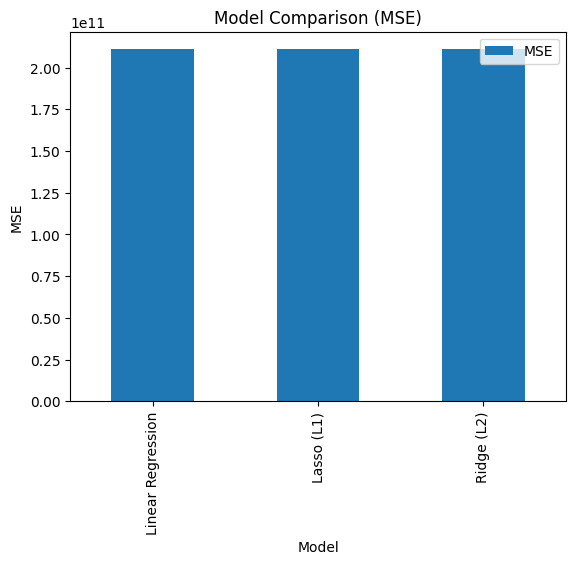

In [ ]:
results_df.plot(x="Model",y="MSE",kind="bar")
plt.title("Model Comparison (MSE)")
plt.ylabel("MSE")
plt.show()

In [ ]:
best_name=results_df.sort_values("R2_Score",ascending=False).iloc[0,0]
best_model=models[best_name]
print("Best Model:",best_name)

Best Model: Linear Regression


In [ ]:
with open("melbourne_best_model.pkl","wb") as f:
    pickle.dump(best_model,f)

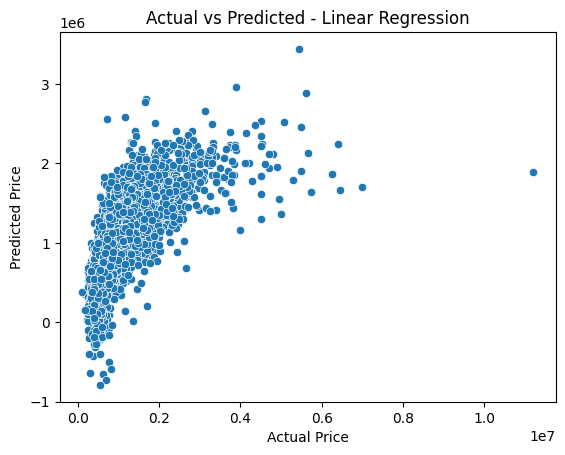

In [ ]:
pred=best_model.predict(X_test)
plot=sns.scatterplot(x=y_test,y=pred,alpha=1)
plot.set_xlabel("Actual Price")
plot.set_ylabel("Predicted Price")
plt.title("Actual vs Predicted - "+best_name)
plt.show()

In [ ]:
print(f"MSE:{mean_squared_error(y_test,pred)}")
print(f"R2 Score:{r2_score(y_test,pred)}")

MSE:210922875735.0012
R2 Score:0.50536950752445
